In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # 10 classes
])

c:\Users\Aditya.konde\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8271 - loss: 0.4794 - val_accuracy: 0.8772 - val_loss: 0.3341
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.8849 - loss: 0.3171 - val_accuracy: 0.8943 - val_loss: 0.2903
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - accuracy: 0.9024 - loss: 0.2678 - val_accuracy: 0.8958 - val_loss: 0.2803
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9128 - loss: 0.2363 - val_accuracy: 0.9050 - val_loss: 0.2578
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9206 - loss: 0.2139 - val_accuracy: 0.9047 - val_loss: 0.2511


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9025 - loss: 0.2726
Test Loss: 0.27262645959854126
Test Accuracy: 0.9024999737739563


In [9]:
predictions = model.predict(X_test)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
for i in range(5):
    pred_class = np.argmax(predictions[i])
    
    print(
        "Actual:", class_names[y_test[i]],
        "Predicted:", class_names[pred_class]
    )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Actual: Ankle boot Predicted: Ankle boot
Actual: Pullover Predicted: Pullover
Actual: Trouser Predicted: Trouser
Actual: Trouser Predicted: Trouser
Actual: Shirt Predicted: Shirt


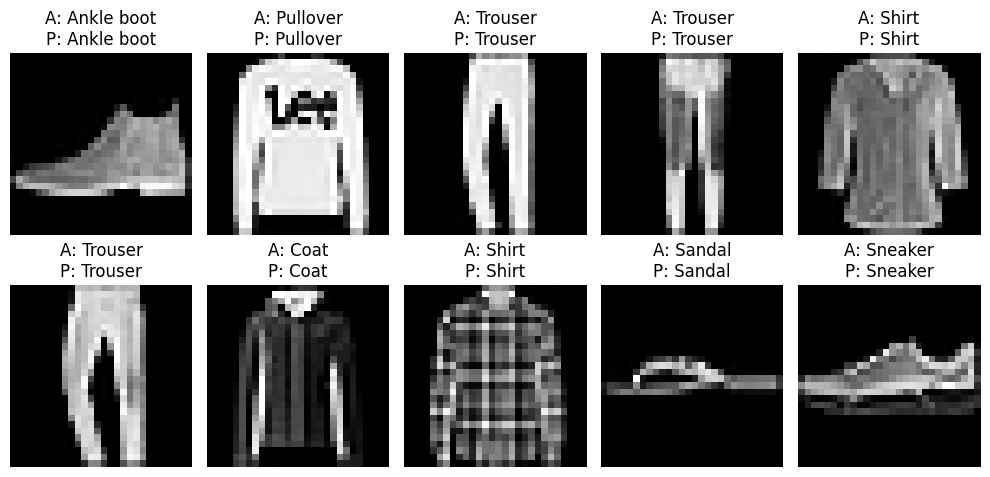

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    
    pred_class = np.argmax(predictions[i])
    
    plt.title(f"A: {class_names[y_test[i]]}\nP: {class_names[pred_class]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

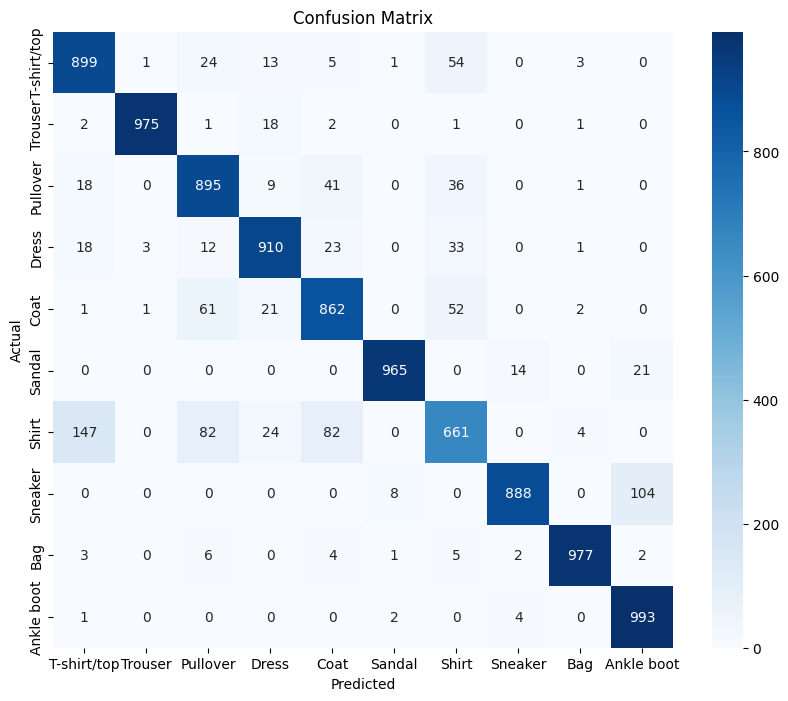

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()